**Approximate String Matching via a Budgeted Lazy DFA — Code Overview.** This notebook implements and evaluates three matchers for the *k-differences* problem, which seeks all positions in a text where a pattern occurs within edit distance *k*. The implementation is developed in seven steps.

**Step 1** introduces the *search DP*, a Sellers-style dynamic programming matcher that computes one edit-distance column for each text character. Because the algorithm is simple, transparent, and easy to verify, it serves both as a baseline and as the ground-truth oracle for the rest of the notebook.

**Step 2** builds the shared engine used by the automaton-based methods. A single function, `step_column`, advances one *capped* edit-distance column (equivalently, one DFA state) by a single input character. The function implements the same recurrence as the dynamic program, while collapsing all error counts greater than *k* into a sentinel value so that the state space remains finite.

**Step 3** uses this engine to construct the *full DFA* following Ukkonen (1985b). The automaton is built by performing a breadth-first search over all reachable states and precomputing every transition. Once the automaton has been constructed, matching reduces to a single table lookup per text character.

**Step 4** presents the main contribution of the notebook: the *budgeted lazy DFA*. Instead of precomputing all reachable states, this method creates states only when they are needed. It caches at most *B* states and, once that budget is exhausted, falls back to direct simulation. The parameter *B* therefore provides a smooth tradeoff between pure simulation (*B* = 0) and the full DFA (*B* = ∞).

**Step 5** focuses on correctness. Randomized differential testing compares both automaton methods against the DP oracle across thousands of randomly generated inputs. The tests include important edge cases such as *k* = 0 and *k* ≥ *m*, ensuring that all subsequent comparisons are made between implementations that have already been validated.

**Step 6** contains the experimental framework. The experiments vary pattern length *m*, error threshold *k*, and alphabet size |Σ| on both random text and a real English corpus. For each configuration, the notebook records operation counts, which serve as the primary implementation-independent performance metric, along with the fallback rate of the budgeted lazy DFA.

**Step 7** visualizes the results through three figures: reachable states versus the theoretical worst-case bound, total work performed by each matching method, and fallback rate as a function of the budget. Running the notebook from top to bottom reproduces the full study. Each section is self-contained and includes a short self-test to verify correctness before proceeding.


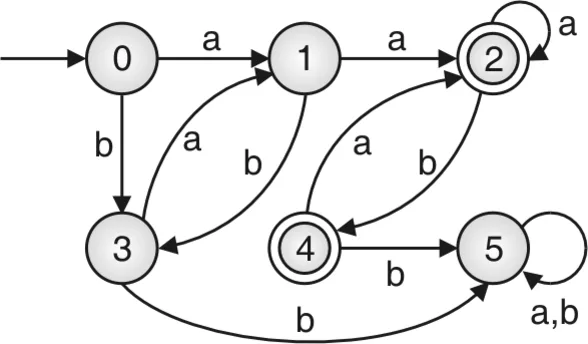

***

In [1]:
# STEP 1 - Search DP  (the correctness oracle & simplest baseline)
# Sellers (1980) search variant of the Wagner-Fischer edit-distance DP.
# Reports END positions (1-indexed) where P matches T within k edits,
# together with the minimum edit distance at each such position.

def search_dp(P, T, k):
    """
    Approximate matching via dynamic programming.

    P : pattern string
    T : text string
    k : max allowed edit distance (>= 0)

    Returns:
      matches : sorted list of (end_pos, dist), end_pos is 1-indexed
      stats   : dict with 'cells' = number of DP cells computed
    """
    m, n = len(P), len(T)
    matches = []
    cells = 0

    # C_0[j] = j : matching P[1..j] against the empty text costs j deletions.
    prev = list(range(m + 1))

    for p in range(1, n + 1):            # p = 1..n  (text position, 1-indexed)
        cur = [0] * (m + 1)
        cur[0] = 0                       # empty prefix costs 0 -> a match may start anywhere
        tp = T[p - 1]                    # current text char (T is 0-indexed in Python)
        for j in range(1, m + 1):
            cost_sub = 0 if tp == P[j - 1] else 1
            cur[j] = min(
                prev[j - 1] + cost_sub,  # match / substitution
                prev[j] + 1,             # insertion in text
                cur[j - 1] + 1,          # deletion from pattern
            )
            cells += 1
        if cur[m] <= k:
            matches.append((p, cur[m]))
        prev = cur

    return matches, {'cells': cells}


# quick self-test so we see it works the moment we run it ----
P, T, k = "cat", "the cart cat dog", 1

matches, stats = search_dp(P, T, k)
print("pattern :", P)
print("text    :", repr(T))
print("k       :", k)
print("matches (end_pos, dist):", matches)
print("DP cells computed      :", stats['cells'])

assert (12, 0) in matches, "expected exact match of 'cat' ending at position 12"
assert any(d == 0 for _, d in matches), "expected at least one exact (dist 0) match"
print("\nself-test passed")

pattern : cat
text    : 'the cart cat dog'
k       : 1
matches (end_pos, dist): [(6, 1), (7, 1), (8, 1), (11, 1), (12, 0), (13, 1)]
DP cells computed      : 48

self-test passed


***

In [2]:
# STEP 2 - NFA column-update step  (shared engine for both DFA methods)
# A DFA "state" is a CAPPED column: a tuple over {0,1,...,k, k+1},
# where the sentinel k+1 means "already more than k errors".
# step_column() advances one state by one character, exactly
# reproducing the search-DP recurrence from Step 1.

def initial_column(m, k):
    """State before reading any text: C_0[j] = min(j, k+1)."""
    CAP = k + 1
    return tuple(min(j, CAP) for j in range(m + 1))

def step_column(col, ch, P, k):
    """
    Advance one capped column by one text character `ch`.

    col : current capped column (tuple, length m+1)
    ch  : the text character just read
    P   : pattern
    k   : max errors

    Returns the next capped column (tuple).
    """
    m = len(P)
    CAP = k + 1
    cur = [0] * (m + 1)
    cur[0] = 0                                  # match may start anywhere
    for j in range(1, m + 1):
        cost_sub = 0 if ch == P[j - 1] else 1
        v = min(
            col[j - 1] + cost_sub,              # match / substitution (diagonal)
            col[j] + 1,                         # insertion in text
            cur[j - 1] + 1,                     # deletion from pattern
        )
        cur[j] = v if v < CAP else CAP          # cap at k+1
    return tuple(cur)

def is_accepting(col, k):
    """A column accepts iff its last entry is <= k (i.e. not the sentinel)."""
    return col[-1] <= k


# self-test: driving step_column across the text must reproduce Step 1
def search_via_columns(P, T, k):
    col = initial_column(len(P), k)
    matches = []
    updates = 0
    for p in range(1, len(T) + 1):
        col = step_column(col, T[p - 1], P, k)
        updates += 1
        if is_accepting(col, k):
            matches.append((p, col[-1]))
    return matches, {'updates': updates}

# standalone copy of the Step 1 oracle, so this cell runs on its own
def search_dp(P, T, k):
    m, n = len(P), len(T); matches = []; prev = list(range(m + 1))
    for p in range(1, n + 1):
        cur = [0]*(m+1); cur[0] = 0; tp = T[p-1]
        for j in range(1, m+1):
            cs = 0 if tp == P[j-1] else 1
            cur[j] = min(prev[j-1]+cs, prev[j]+1, cur[j-1]+1)
        if cur[m] <= k: matches.append((p, cur[m]))
        prev = cur
    return matches

P, T, k = "cat", "the cart cat dog", 1

col_matches, stats = search_via_columns(P, T, k)
dp_matches = search_dp(P, T, k)

print("pattern :", P)
print("text    :", repr(T))
print("k       :", k)
print("initial column     :", initial_column(len(P), k))
print("column-method match:", col_matches)
print("DP-oracle match    :", dp_matches)
print("column updates     :", stats['updates'])

assert col_matches == dp_matches, "column method disagrees with DP oracle!"
print("\nself-test passed  (column method == DP oracle)")

pattern : cat
text    : 'the cart cat dog'
k       : 1
initial column     : (0, 1, 2, 2)
column-method match: [(6, 1), (7, 1), (8, 1), (11, 1), (12, 0), (13, 1)]
DP-oracle match    : [(6, 1), (7, 1), (8, 1), (11, 1), (12, 0), (13, 1)]
column updates     : 16

self-test passed  (column method == DP oracle)


***

In [4]:
# STEP 2 - NFA column-update step  (shared engine for both DFA methods)
# A DFA "state" is a CAPPED column: a tuple over {0,1,...,k, k+1},
# where the sentinel k+1 means "already more than k errors".
# step_column() advances one state by one character, exactly
# reproducing the search-DP recurrence from Step 1.

def initial_column(m, k):
    """State before reading any text: C_0[j] = min(j, k+1)."""
    CAP = k + 1
    return tuple(min(j, CAP) for j in range(m + 1))

def step_column(col, ch, P, k):
    """
    Advance one capped column by one text character `ch`.

    col : current capped column (tuple, length m+1)
    ch  : the text character just read
    P   : pattern
    k   : max errors

    Returns the next capped column (tuple).
    """
    m = len(P)
    CAP = k + 1
    cur = [0] * (m + 1)
    cur[0] = 0                                  # match may start anywhere
    for j in range(1, m + 1):
        cost_sub = 0 if ch == P[j - 1] else 1
        v = min(
            col[j - 1] + cost_sub,              # match / substitution (diagonal)
            col[j] + 1,                         # insertion in text
            cur[j - 1] + 1,                     # deletion from pattern
        )
        cur[j] = v if v < CAP else CAP          # cap at k+1
    return tuple(cur)

def is_accepting(col, k):
    """A column accepts iff its last entry is <= k (i.e. not the sentinel)."""
    return col[-1] <= k


#  self-test: driving step_column across the text must reproduce Step 1
def search_via_columns(P, T, k):
    col = initial_column(len(P), k)
    matches = []
    updates = 0
    for p in range(1, len(T) + 1):
        col = step_column(col, T[p - 1], P, k)
        updates += 1
        if is_accepting(col, k):
            matches.append((p, col[-1]))
    return matches, {'updates': updates}

# standalone copy of the Step 1 oracle, so this cell runs on its own
def search_dp(P, T, k):
    m, n = len(P), len(T); matches = []; prev = list(range(m + 1))
    for p in range(1, n + 1):
        cur = [0]*(m+1); cur[0] = 0; tp = T[p-1]
        for j in range(1, m+1):
            cs = 0 if tp == P[j-1] else 1
            cur[j] = min(prev[j-1]+cs, prev[j]+1, cur[j-1]+1)
        if cur[m] <= k: matches.append((p, cur[m]))
        prev = cur
    return matches

P, T, k = "cat", "the cart cat dog", 1

col_matches, stats = search_via_columns(P, T, k)
dp_matches = search_dp(P, T, k)

print("pattern :", P)
print("text    :", repr(T))
print("k       :", k)
print("initial column     :", initial_column(len(P), k))
print("column-method match:", col_matches)
print("DP-oracle match    :", dp_matches)
print("column updates     :", stats['updates'])

assert col_matches == dp_matches, "column method disagrees with DP oracle!"
print("\nself-test passed  (column method == DP oracle)")

pattern : cat
text    : 'the cart cat dog'
k       : 1
initial column     : (0, 1, 2, 2)
column-method match: [(6, 1), (7, 1), (8, 1), (11, 1), (12, 0), (13, 1)]
DP-oracle match    : [(6, 1), (7, 1), (8, 1), (11, 1), (12, 0), (13, 1)]
column updates     : 16

self-test passed  (column method == DP oracle)


***

In [5]:
# STEP 3 - Full DFA
# Phase 1 (build): BFS over reachable capped columns, precomputing
#                  delta[state][char] for every alphabet symbol.
# Phase 2 (scan) : one table lookup per text character -> O(n) matching.
# Key measurement: number of reachable states (columns) built.


from collections import deque

# shared engine from Step 2 (re-included so the cell is standalone)
def initial_column(m, k):
    CAP = k + 1
    return tuple(min(j, CAP) for j in range(m + 1))

def step_column(col, ch, P, k):
    m = len(P); CAP = k + 1
    cur = [0] * (m + 1); cur[0] = 0
    for j in range(1, m + 1):
        cs = 0 if ch == P[j - 1] else 1
        v = min(col[j - 1] + cs, col[j] + 1, cur[j - 1] + 1)
        cur[j] = v if v < CAP else CAP
    return tuple(cur)

def is_accepting(col, k):
    return col[-1] <= k

def build_full_dfa(P, k, alphabet):
    """
    Build the full DFA transition table by BFS over reachable columns.

    Returns:
      delta   : dict  state -> {char -> next_state}
      start   : the initial state
      accept  : set of accepting states
      stats   : {'states_built', 'updates'}  (updates = column recomputations)
    """
    start = initial_column(len(P), k)
    delta = {}
    accept = set()
    updates = 0

    queue = deque([start])
    seen = {start}
    while queue:
        state = queue.popleft()
        if is_accepting(state, k):
            accept.add(state)
        row = {}
        for ch in alphabet:
            nxt = step_column(state, ch, P, k)   # one engine call
            updates += 1
            row[ch] = nxt
            if nxt not in seen:
                seen.add(nxt)
                queue.append(nxt)
        delta[state] = row

    return delta, start, accept, {'states_built': len(seen), 'updates': updates}

def scan_full_dfa(delta, start, accept, T, k):
    """Phase 2: scan text with one lookup per character."""
    state = start
    matches = []
    lookups = 0
    for p in range(1, len(T) + 1):
        state = delta[state][T[p - 1]]           # O(1) table lookup
        lookups += 1
        if state in accept:
            matches.append((p, state[-1]))
    return matches, {'lookups': lookups}

# self-test
def search_dp(P, T, k):
    m, n = len(P), len(T); matches = []; prev = list(range(m + 1))
    for p in range(1, n + 1):
        cur = [0]*(m+1); cur[0] = 0; tp = T[p-1]
        for j in range(1, m+1):
            cs = 0 if tp == P[j-1] else 1
            cur[j] = min(prev[j-1]+cs, prev[j]+1, cur[j-1]+1)
        if cur[m] <= k: matches.append((p, cur[m]))
        prev = cur
    return matches

P, T, k = "cat", "the cart cat dog", 1
alphabet = sorted(set(T))          # build over the symbols that actually occur

delta, start, accept, bstats = build_full_dfa(P, k, alphabet)
dfa_matches, sstats = scan_full_dfa(delta, start, accept, T, k)
dp_matches = search_dp(P, T, k)

print("pattern :", P, "| k :", k, "| |alphabet| :", len(alphabet))
print("full-DFA match :", dfa_matches)
print("DP-oracle match:", dp_matches)
print("reachable states built :", bstats['states_built'])
print("build-phase updates    :", bstats['updates'], "(= states_built * |alphabet| roughly)")
print("scan-phase lookups     :", sstats['lookups'], "(= n)")

assert dfa_matches == dp_matches, "full DFA disagrees with oracle!"
print("\nself-test passed  (full DFA == DP oracle)")

pattern : cat | k : 1 | |alphabet| : 10
full-DFA match : [(6, 1), (7, 1), (8, 1), (11, 1), (12, 0), (13, 1)]
DP-oracle match: [(6, 1), (7, 1), (8, 1), (11, 1), (12, 0), (13, 1)]
reachable states built : 8
build-phase updates    : 80 (= states_built * |alphabet| roughly)
scan-phase lookups     : 16 (= n)

self-test passed  (full DFA == DP oracle)


****

In [7]:

# STEP 4 - Budgeted lazy DFA  (our contribution)
# Lazily determinizes the k-differences automaton: transitions are
# computed on demand and CACHED, but the cache holds at most B states.
# Cache hit  -> O(1) lookup (like the full DFA).
# Cache miss -> O(m) direct column update (like NFA simulation);
#               stored only if the cache still has room (< B states).
#
#   B = 0        -> pure NFA simulation (never caches)
#   B = infinite -> full DFA, built lazily
#   0 < B < all  -> hybrid; some characters fall back to simulation
#
# Measurements: cache hits, misses, and fallback rate = misses / n.


# shared engine (standalone)
def initial_column(m, k):
    CAP = k + 1
    return tuple(min(j, CAP) for j in range(m + 1))

def step_column(col, ch, P, k):
    m = len(P); CAP = k + 1
    cur = [0] * (m + 1); cur[0] = 0
    for j in range(1, m + 1):
        cs = 0 if ch == P[j - 1] else 1
        v = min(col[j - 1] + cs, col[j] + 1, cur[j - 1] + 1)
        cur[j] = v if v < CAP else CAP
    return tuple(cur)

def is_accepting(col, k):
    return col[-1] <= k


def scan_budgeted_lazy_dfa(P, T, k, B):
    """
    Scan T with a lazily-built, size-capped transition cache.

    B : max number of states whose transitions we cache
        (use float('inf') for an unbounded lazy DFA)

    Returns matches and stats {hits, misses, states_cached, fallback_rate}.
    """
    start = initial_column(len(P), k)
    cache = {}                       # state -> {char -> next_state}
    hits = misses = 0

    state = start
    matches = []
    for p in range(1, len(T) + 1):
        ch = T[p - 1]
        row = cache.get(state)
        if row is not None and ch in row:
            nxt = row[ch]            # cache hit: O(1)
            hits += 1
        else:
            nxt = step_column(state, ch, P, k)   # cache miss: O(m) fallback
            misses += 1
            if len(cache) < B or state in cache:
                # room to cache (or this state already has a partial row)
                cache.setdefault(state, {})[ch] = nxt
        state = nxt
        if is_accepting(state, k):
            matches.append((p, state[-1]))

    n = len(T)
    stats = {
        'hits': hits,
        'misses': misses,
        'states_cached': len(cache),
        'fallback_rate': misses / n if n else 0.0,
    }
    return matches, stats


# self-test: every budget must agree with the oracle
def search_dp(P, T, k):
    m, n = len(P), len(T); matches = []; prev = list(range(m + 1))
    for p in range(1, n + 1):
        cur = [0]*(m+1); cur[0] = 0; tp = T[p-1]
        for j in range(1, m+1):
            cs = 0 if tp == P[j-1] else 1
            cur[j] = min(prev[j-1]+cs, prev[j]+1, cur[j-1]+1)
        if cur[m] <= k: matches.append((p, cur[m]))
        prev = cur
    return matches

P, T, k = "cat", "the cart cat dog", 1
truth = search_dp(P, T, k)

print("pattern :", P, "| k :", k, "| n :", len(T))
print("oracle matches:", truth)
print()
print(f"{'budget B':>10} | {'matches ok':>10} | {'hits':>5} | {'misses':>6} | {'cached':>6} | {'fallback rate':>13}")
print("-" * 70)
for B in [0, 3, float('inf')]:
    m_out, s = scan_budgeted_lazy_dfa(P, T, k, B)
    ok = (m_out == truth)
    Blabel = "inf" if B == float('inf') else str(B)
    print(f"{Blabel:>10} | {str(ok):>10} | {s['hits']:>5} | {s['misses']:>6} | {s['states_cached']:>6} | {s['fallback_rate']:>13.3f}")
    assert ok, f"budget {Blabel} disagrees with oracle!"

print("\nself-test passed  (all budgets == DP oracle)")

pattern : cat | k : 1 | n : 16
oracle matches: [(6, 1), (7, 1), (8, 1), (11, 1), (12, 0), (13, 1)]

  budget B | matches ok |  hits | misses | cached | fallback rate
----------------------------------------------------------------------
         0 |       True |     0 |     16 |      0 |         1.000
         3 |       True |     2 |     14 |      3 |         0.875
       inf |       True |     2 |     14 |      6 |         0.875

self-test passed  (all budgets == DP oracle)


***

In [8]:
# STEP 5 - Randomized differential testing  (correctness gate, section 6.5)
# Consolidates all three matchers, then checks that the full DFA and the
# budgeted lazy DFA (several budgets) agree with the search-DP oracle on
# thousands of random cases, including edge cases k=0 and k>=m.
# Fixed seed => fully reproducible.

import random
from collections import deque

#  shared engine
def initial_column(m, k):
    CAP = k + 1
    return tuple(min(j, CAP) for j in range(m + 1))

def step_column(col, ch, P, k):
    m = len(P); CAP = k + 1
    cur = [0] * (m + 1); cur[0] = 0
    for j in range(1, m + 1):
        cs = 0 if ch == P[j - 1] else 1
        v = min(col[j - 1] + cs, col[j] + 1, cur[j - 1] + 1)
        cur[j] = v if v < CAP else CAP
    return tuple(cur)

def is_accepting(col, k):
    return col[-1] <= k

#  1) search DP (oracle)
def search_dp(P, T, k):
    m, n = len(P), len(T); matches = []; prev = list(range(m + 1))
    for p in range(1, n + 1):
        cur = [0]*(m+1); cur[0] = 0; tp = T[p-1]
        for j in range(1, m+1):
            cs = 0 if tp == P[j-1] else 1
            cur[j] = min(prev[j-1]+cs, prev[j]+1, cur[j-1]+1)
        if cur[m] <= k: matches.append((p, cur[m]))
        prev = cur
    return matches

#  2) full DFA
def build_full_dfa(P, k, alphabet):
    start = initial_column(len(P), k); delta = {}; accept = set()
    queue = deque([start]); seen = {start}
    while queue:
        state = queue.popleft()
        if is_accepting(state, k): accept.add(state)
        row = {}
        for ch in alphabet:
            nxt = step_column(state, ch, P, k); row[ch] = nxt
            if nxt not in seen: seen.add(nxt); queue.append(nxt)
        delta[state] = row
    return delta, start, accept

def scan_full_dfa(P, T, k, alphabet):
    delta, start, accept = build_full_dfa(P, k, alphabet)
    state = start; matches = []
    for p in range(1, len(T) + 1):
        state = delta[state][T[p - 1]]
        if state in accept: matches.append((p, state[-1]))
    return matches

#  3) budgeted lazy DFA
def scan_budgeted_lazy_dfa(P, T, k, B):
    start = initial_column(len(P), k); cache = {}
    state = start; matches = []
    for p in range(1, len(T) + 1):
        ch = T[p - 1]; row = cache.get(state)
        if row is not None and ch in row:
            nxt = row[ch]
        else:
            nxt = step_column(state, ch, P, k)
            if len(cache) < B or state in cache:
                cache.setdefault(state, {})[ch] = nxt
        state = nxt
        if is_accepting(state, k): matches.append((p, state[-1]))
    return matches

# Differential test harness
def run_difftest(trials=5000, seed=12345, verbose_fail=True):
    rng = random.Random(seed)
    alph_sizes = [2, 4, 20, 26]
    passed = 0
    edge_k_ge_m = 0
    edge_k0 = 0

    for t in range(trials):
        sigma = rng.choice(alph_sizes)
        alphabet = [chr(ord('a') + i) for i in range(sigma)]
        m = rng.randint(1, 8)
        n = rng.randint(1, 40)
        # bias k toward interesting values, occasionally k >= m
        k = rng.choice([0, 0, 1, 1, 2, 3, rng.randint(0, m + 1)])
        P = ''.join(rng.choice(alphabet) for _ in range(m))
        T = ''.join(rng.choice(alphabet) for _ in range(n))

        if k == 0: edge_k0 += 1
        if k >= m: edge_k_ge_m += 1

        truth = search_dp(P, T, k)
        cand = {
            'full_dfa'   : scan_full_dfa(P, T, k, alphabet),
            'lazy_B0'    : scan_budgeted_lazy_dfa(P, T, k, 0),
            'lazy_B4'    : scan_budgeted_lazy_dfa(P, T, k, 4),
            'lazy_Binf'  : scan_budgeted_lazy_dfa(P, T, k, float('inf')),
        }
        for name, out in cand.items():
            if out != truth:
                if verbose_fail:
                    print("MISMATCH!")
                    print("  method :", name)
                    print("  P, T, k:", repr(P), repr(T), k)
                    print("  oracle :", truth)
                    print("  got    :", out)
                return False, {'passed': passed}
        passed += 1

    return True, {
        'passed': passed, 'trials': trials,
        'edge_k0': edge_k0, 'edge_k_ge_m': edge_k_ge_m,
    }

ok, stats = run_difftest(trials=5000, seed=12345)
print("differential test:", "PASSED" if ok else "FAILED")
print("cases checked     :", stats['passed'], "/", stats.get('trials'))
print("  of which k = 0  :", stats['edge_k0'], "(exact-matching cases)")
print("  of which k >= m :", stats['edge_k_ge_m'], "(degenerate 'everything matches' cases)")
print("methods compared per case: full_dfa, lazy_B0, lazy_B4, lazy_Binf  (all vs. DP oracle)")

differential test: PASSED
cases checked     : 5000 / 5000
  of which k = 0  : 1557 (exact-matching cases)
  of which k >= m : 900 (degenerate 'everything matches' cases)
methods compared per case: full_dfa, lazy_B0, lazy_B4, lazy_Binf  (all vs. DP oracle)


***

In [11]:
# STEP 6 - Experiment driver  (fully self-contained)
# Defines all matchers internally so it runs regardless of earlier cells.

import random, urllib.request

# ---------------- shared engine ----------------
def initial_column(m, k):
    CAP = k + 1
    return tuple(min(j, CAP) for j in range(m + 1))

def step_column(col, ch, P, k):
    m = len(P); CAP = k + 1
    cur = [0]*(m+1); cur[0] = 0
    for j in range(1, m+1):
        cs = 0 if ch == P[j-1] else 1
        v = min(col[j-1]+cs, col[j]+1, cur[j-1]+1)
        cur[j] = v if v < CAP else CAP
    return tuple(cur)

def is_accepting(col, k):
    return col[-1] <= k

#  1) search DP (oracle)
def search_dp(P, T, k):
    m, n = len(P), len(T); matches = []; prev = list(range(m+1))
    for p in range(1, n+1):
        cur = [0]*(m+1); cur[0] = 0; tp = T[p-1]
        for j in range(1, m+1):
            cs = 0 if tp == P[j-1] else 1
            cur[j] = min(prev[j-1]+cs, prev[j]+1, cur[j-1]+1)
        if cur[m] <= k: matches.append((p, cur[m]))
        prev = cur
    return matches

#  2) full DFA (with build instrumentation)
def build_full_dfa(P, k, alphabet):
    start = initial_column(len(P), k); delta = {}; accept = set()
    q = deque([start]); seen = {start}; calls = 0
    while q:
        s = q.popleft()
        if is_accepting(s, k): accept.add(s)
        row = {}
        for ch in alphabet:
            nxt = step_column(s, ch, P, k); calls += 1; row[ch] = nxt
            if nxt not in seen: seen.add(nxt); q.append(nxt)
        delta[s] = row
    return delta, start, accept, {'states_built': len(seen), 'build_calls': calls}

def scan_full_dfa_prebuilt(delta, start, accept, T):
    s = start; matches = []
    for p in range(1, len(T)+1):
        s = delta[s][T[p-1]]
        if s in accept: matches.append((p, s[-1]))
    return matches

#  3) budgeted lazy DFA (returns matches, stats)
def scan_budgeted_lazy_dfa(P, T, k, B):
    start = initial_column(len(P), k); cache = {}
    s = start; matches = []; hits = miss = 0
    for p in range(1, len(T)+1):
        ch = T[p-1]; row = cache.get(s)
        if row is not None and ch in row:
            nxt = row[ch]; hits += 1
        else:
            nxt = step_column(s, ch, P, k); miss += 1
            if len(cache) < B or s in cache:
                cache.setdefault(s, {})[ch] = nxt
        s = nxt
        if is_accepting(s, k):
            matches.append((p, s[-1]))
    n = len(T)
    return matches, {'hits': hits, 'misses': miss,
                     'states_cached': len(cache),
                     'fallback_rate': miss/n if n else 0.0}

#  experiment configuration
SEED   = 2026
N_TEXT = 10000
KS     = [1, 2, 3]
MS     = [4, 8, 12, 16, 20, 24, 28, 32]
SIGMAS = [2, 4, 20, 26]

def make_alphabet(sigma): return [chr(ord('a') + i) for i in range(sigma)]
def random_text(sigma, n, rng):
    alph = make_alphabet(sigma)
    return ''.join(rng.choice(alph) for _ in range(n)), alph
def sample_pattern(text, m, rng):
    i = rng.randint(0, len(text) - m); return text[i:i+m]
def crude_bound(m, k): return (k + 2) ** (m + 1)

def one_config(P, T, k, alphabet):
    m, n = len(P), len(T)
    dp_matches = search_dp(P, T, k)
    delta, start, accept, bstats = build_full_dfa(P, k, alphabet)
    full_matches = scan_full_dfa_prebuilt(delta, start, accept, T)
    lazy_matches, lstats = scan_budgeted_lazy_dfa(P, T, k, float('inf'))
    assert dp_matches == full_matches == lazy_matches, "method disagreement in sweep!"
    return {
        'sigma': len(alphabet), 'm': m, 'k': k, 'n': n,
        'states_built': bstats['states_built'],
        'crude_bound': crude_bound(m, k),
        'dp_cellops': n * m,
        'full_build_cellops': bstats['build_calls'] * m,
        'lazy_cellops': lstats['misses'] * m,
        'lazy_states_cached': lstats['states_cached'],
        'lazy_fallback_rate': lstats['fallback_rate'],
        'n_matches': len(dp_matches),
    }

def run_sweep():
    rng = random.Random(SEED); rows = []
    for sigma in SIGMAS:
        T, alph = random_text(sigma, N_TEXT, rng)
        for m in MS:
            P = sample_pattern(T, m, rng)
            for k in KS:
                rows.append(one_config(P, T, k, alph))
    return rows

def run_budget_sweep():
    rng = random.Random(SEED + 1)
    sigma, m, k = 4, 16, 2
    T, alph = random_text(sigma, N_TEXT, rng)
    P = sample_pattern(T, m, rng)
    _, _, _, bstats = build_full_dfa(P, k, alph)
    reachable = bstats['states_built']; rows = []
    for B in [0, 1, 2, 4, 8, 16, 32, 64, 128, 256, float('inf')]:
        _, s = scan_budgeted_lazy_dfa(P, T, k, B)
        rows.append({'B': B, 'sigma': sigma, 'm': m, 'k': k,
                     'fallback_rate': s['fallback_rate'],
                     'states_cached': s['states_cached'],
                     'reachable_states': reachable})
    return rows, reachable

def load_english(n, rng):
    url = "https://www.gutenberg.org/files/1342/1342-0.txt"
    try:
        raw = urllib.request.urlopen(url, timeout=15).read().decode('utf-8', 'ignore')
        source = "Project Gutenberg #1342 (Pride and Prejudice)"
    except Exception:
        raw = ("it is a truth universally acknowledged that a single man in "
               "possession of a good fortune must be in want of a wife ") * 4000
        source = "OFFLINE FALLBACK (run in Colab for the real book)"
    text = ''.join(c.lower() for c in raw if c.isalpha() or c == ' ')
    text = text[5000:5000 + n]
    return text, sorted(set(text)), source

def run_english():
    rng = random.Random(SEED + 2)
    T, alph, source = load_english(N_TEXT, rng); rows = []
    for m in MS:
        P = sample_pattern(T, m, rng)
        for k in KS:
            r = one_config(P, T, k, alph); r['source'] = 'english'; rows.append(r)
    return rows, alph, source

RESULTS_SWEEP = run_sweep()
RESULTS_BUDGET, BUDGET_REACHABLE = run_budget_sweep()
RESULTS_ENGLISH, ENG_ALPH, ENG_SOURCE = run_english()

#  summaries
print("=== SWEEP (random text) : %d configs ===" % len(RESULTS_SWEEP))
print("english source:", ENG_SOURCE, "| |alphabet| =", len(ENG_ALPH), "\n")
print("sample rows (sigma=4, k=2, random text):")
print(f"{'m':>3} {'k':>2} {'states':>7} {'crude_bound':>14} {'dp_cellops':>11} {'full_build':>11} {'lazy_cellops':>12} {'fallback':>9}")
for r in RESULTS_SWEEP:
    if r['sigma'] == 4 and r['k'] == 2:
        print(f"{r['m']:>3} {r['k']:>2} {r['states_built']:>7} {r['crude_bound']:>14} "
              f"{r['dp_cellops']:>11} {r['full_build_cellops']:>11} {r['lazy_cellops']:>12} {r['lazy_fallback_rate']:>9.4f}")

print("\n=== BUDGET SWEEP (sigma=4, m=16, k=2, reachable states = %d) ===" % BUDGET_REACHABLE)
print(f"{'B':>6} {'states_cached':>14} {'fallback_rate':>14}")
for r in RESULTS_BUDGET:
    Blab = 'inf' if r['B'] == float('inf') else str(r['B'])
    print(f"{Blab:>6} {r['states_cached']:>14} {r['fallback_rate']:>14.4f}")

print("\n=== ENGLISH (real text) : sample rows (k=2) ===")
print(f"{'m':>3} {'k':>2} {'states':>7} {'dp_cellops':>11} {'full_build':>11} {'lazy_cellops':>12} {'fallback':>9}")
for r in RESULTS_ENGLISH:
    if r['k'] == 2:
        print(f"{r['m']:>3} {r['k']:>2} {r['states_built']:>7} {r['dp_cellops']:>11} "
              f"{r['full_build_cellops']:>11} {r['lazy_cellops']:>12} {r['lazy_fallback_rate']:>9.4f}")


=== SWEEP (random text) : 96 configs ===
english source: Project Gutenberg #1342 (Pride and Prejudice) | |alphabet| = 27 

sample rows (sigma=4, k=2, random text):
  m  k  states    crude_bound  dp_cellops  full_build lazy_cellops  fallback
  4  2      21           1024       40000         336          324    0.0081
  8  2     134         262144       80000        4288         2240    0.0280
 12  2     397       67108864      120000       19056         3216    0.0268
 16  2     537    17179869184      160000       34368         4992    0.0312
 20  2     747  4398046511104      200000       59760         6320    0.0316
 24  2     909 1125899906842624      240000       87264         7800    0.0325
 28  2    1120 288230376151711744      280000      125440        10500    0.0375
 32  2    1298 73786976294838206464      320000      166144        10432    0.0326

=== BUDGET SWEEP (sigma=4, m=16, k=2, reachable states = 529) ===
     B  states_cached  fallback_rate
     0              0      

***

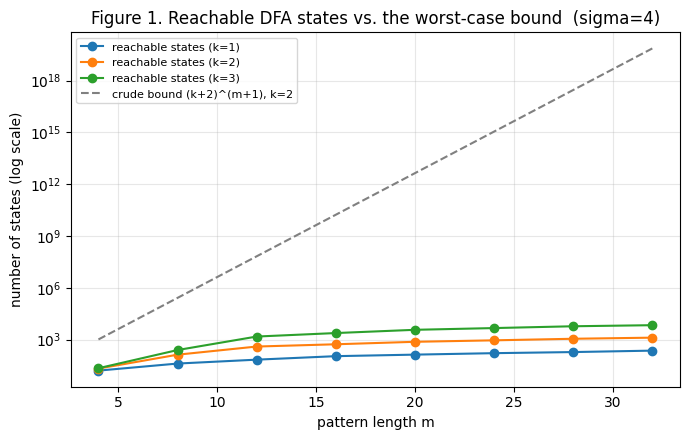

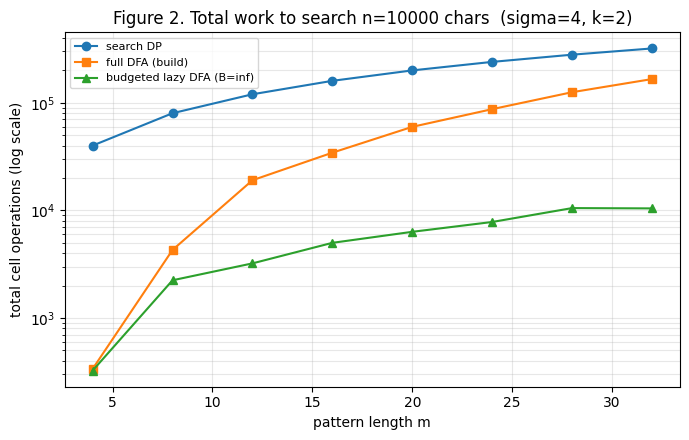

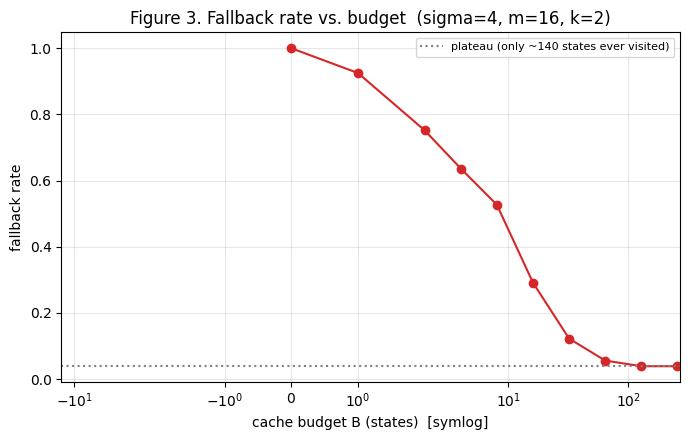

saved fig1_states.png, fig2_work.png, fig3_fallback.png
visited states on budget-sweep text: 140 | reachable: 529


In [12]:
# STEP 7 - Plots  (uses RESULTS_SWEEP, RESULTS_BUDGET, RESULTS_ENGLISH from Step 6)
# Produces the three figures the Results section needs.
import matplotlib.pyplot as plt

def rows_where(rows, **cond):
    out = [r for r in rows if all(r[k] == v for k, v in cond.items())]
    return sorted(out, key=lambda r: r.get('m', 0))

# FIGURE 1: reachable states vs m, with the crude bound
fig1, ax = plt.subplots(figsize=(7, 4.5))
for k in [1, 2, 3]:
    rs = rows_where(RESULTS_SWEEP, sigma=4, k=k)
    ax.plot([r['m'] for r in rs], [r['states_built'] for r in rs],
            marker='o', label=f'reachable states (k={k})')
rs2 = rows_where(RESULTS_SWEEP, sigma=4, k=2)
ax.plot([r['m'] for r in rs2], [r['crude_bound'] for r in rs2],
        '--', color='gray', label='crude bound (k+2)^(m+1), k=2')
ax.set_yscale('log')
ax.set_xlabel('pattern length m'); ax.set_ylabel('number of states (log scale)')
ax.set_title('Figure 1. Reachable DFA states vs. the worst-case bound  (sigma=4)')
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)
fig1.tight_layout(); fig1.savefig('fig1_states.png', dpi=130); plt.show()

# FIGURE 2: total work vs m (DP vs full DFA vs lazy DFA)
fig2, ax = plt.subplots(figsize=(7, 4.5))
rs = rows_where(RESULTS_SWEEP, sigma=4, k=2)
ms = [r['m'] for r in rs]
ax.plot(ms, [r['dp_cellops'] for r in rs],         marker='o', label='search DP')
ax.plot(ms, [r['full_build_cellops'] for r in rs], marker='s', label='full DFA (build)')
ax.plot(ms, [r['lazy_cellops'] for r in rs],       marker='^', label='budgeted lazy DFA (B=inf)')
ax.set_yscale('log')
ax.set_xlabel('pattern length m'); ax.set_ylabel('total cell operations (log scale)')
ax.set_title('Figure 2. Total work to search n=10000 chars  (sigma=4, k=2)')
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)
fig2.tight_layout(); fig2.savefig('fig2_work.png', dpi=130); plt.show()

# FIGURE 3: fallback rate vs budget B
fig3, ax = plt.subplots(figsize=(7, 4.5))
finite = [r for r in RESULTS_BUDGET if r['B'] != float('inf')]
Bs = [r['B'] for r in finite]
fr = [r['fallback_rate'] for r in finite]
reach   = RESULTS_BUDGET[0]['reachable_states']
visited = max(r['states_cached'] for r in RESULTS_BUDGET)
ax.plot(Bs, fr, marker='o', color='tab:red')
ax.axhline(min(fr), ls=':', color='gray',
           label=f'plateau (only ~{visited} states ever visited)')
ax.set_xscale('symlog')
ax.set_xlabel('cache budget B (states)  [symlog]'); ax.set_ylabel('fallback rate')
ax.set_title('Figure 3. Fallback rate vs. budget  (sigma=4, m=16, k=2)')
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)
fig3.tight_layout(); fig3.savefig('fig3_fallback.png', dpi=130); plt.show()

print("saved fig1_states.png, fig2_work.png, fig3_fallback.png")
print("visited states on budget-sweep text:", visited, "| reachable:", reach)

***

✅